--- Stage 1: Loading and Processing Data ---
Successfully loaded JSON file from: C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data\json_2408\patches_coco_with_original_bbox.json
Successfully processed 10860 annotations.

--- Stage 2: Summary Statistics and Visualization ---
Detailed statistics on cell height by class:
             count       mean        std   min   25%   50%   75%    max
class_name                                                             
cbc          744.0  64.137097  15.791628  31.0  54.0  64.0  71.0  127.0
other       7559.0  60.049874  20.240706  10.0  47.0  61.0  72.0  144.0
rbc         2557.0  65.569026  12.796791  31.0  58.0  65.0  71.0  133.0

--- Stage 3: Training and Optimizing a Classifier ---
Data split into 7602 training samples and 3258 testing samples.

Optimizing model with GridSearchCV (focused on F1-score)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Optimization complete.
Best parameters found: {'cr

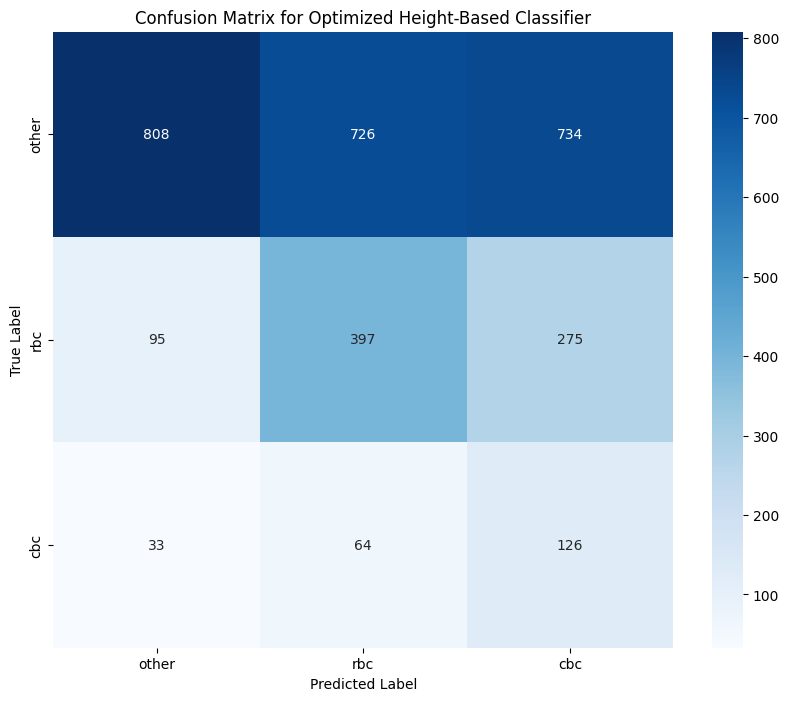

In [2]:
# ─── 1) Imports & Setup ───────────────────────────────────────────
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ─── 2) File Path ────────────────────────────────────────────────
JSON_PATH = r'C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data\json_2408\patches_coco_with_original_bbox.json'


# ─── 3) Load and Process Data ───────────────────────────────────────
print("--- Stage 1: Loading and Processing Data ---")
try:
    with open(JSON_PATH, 'r') as f:
        coco_data = json.load(f)
    print(f"Successfully loaded JSON file from: {JSON_PATH}")
except FileNotFoundError:
    print(f"--- ERROR: FILE NOT FOUND ---")
    coco_data = None

if coco_data and coco_data.get('annotations'):
    annotations = coco_data['annotations']
    data_list = []
    for ann in annotations:
        if 'original_bbox' in ann and ann['original_bbox']:
            min_y, _, max_y, _ = ann['original_bbox']
            height = max_y - min_y
            data_list.append({
                'height': height,
                'class_id': ann['category_id']
            })

    df = pd.DataFrame(data_list)
    CLASS_MAP = {0: 'other', 1: 'rbc', 2: 'cbc'}
    df['class_name'] = df['class_id'].map(CLASS_MAP)
    print(f"Successfully processed {len(df)} annotations.")

    # ─── 4) Summary Statistics & Visualization ────────────────────────
    print("\n--- Stage 2: Summary Statistics and Visualization ---")
    print("Detailed statistics on cell height by class:")
    print(df.groupby('class_name')['height'].describe())


    # ─── 5) Model Training and Optimization (MODIFIED FOR IMBALANCE) ───
    print("\n--- Stage 3: Training and Optimizing a Classifier ---")
    
    X = df[['height']]
    y = df['class_id']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    print(f"Data split into {len(X_train)} training samples and {len(X_test)} testing samples.")

    # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★ CHANGE #1 ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
    # Add class_weight='balanced' to penalize mistakes on the minority
    # classes ('rbc', 'cbc') more heavily.
    model = RandomForestClassifier(random_state=42, class_weight='balanced')
    # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
    
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 20],
        'min_samples_leaf': [2, 4, 6],
        'criterion': ['gini', 'entropy']
    }

    # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★ CHANGE #2 ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
    # Change the scoring metric from default 'accuracy' to 'f1_weighted'.
    # This finds the model that is best at balancing precision and recall
    # across all classes, which is much better for imbalanced data.
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1, scoring='f1_weighted')
    # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
    
    print("\nOptimizing model with GridSearchCV (focused on F1-score)...")
    grid_search.fit(X_train, y_train)

    print("\nOptimization complete.")
    print(f"Best parameters found: {grid_search.best_params_}")
    best_model = grid_search.best_estimator_

    # ─── 6) Model Evaluation ────────────────────────────────────────────
    print("\n--- Stage 4: Evaluating the Optimized Model ---")
    y_pred = best_model.predict(X_test)

    print("\nClassification Report:")
    report = classification_report(y_test, y_pred, target_names=CLASS_MAP.values())
    print(report)

    print("Generating confusion matrix plot...")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_MAP.values(), yticklabels=CLASS_MAP.values())
    plt.title('Confusion Matrix for Optimized Height-Based Classifier')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig('optimized_height_classifier_confusion_matrix.png')
    print("Saved confusion matrix plot to 'optimized_height_classifier_confusion_matrix.png'")
    print("\n--- Analysis Complete ---")